In [1]:
import torch
import numpy as np

def phong_model(sdf, points, camera_position, ambient_coeff, diffuse_coeff, specular_coeff, shininess):
    # define
    amb_light_color = torch.tensor([0.15, 0, 0])
    light_color = torch.tensor([1.0, 1.0, 1.0])
    # point light
    light_intensity_1 = 1.
    light_position_1 = torch.tensor([1., 1., 1.])
    # area light
    light_intensity_2 = 0.5
    light_dir_2 = torch.tensor([0., 0., -1.])

    normals = estimate_normals(sdf, points)
    view_dirs = points - camera_position
    light_dir_1 = points - light_position_1
    light_dir_2 = light_dir_2.repeat(points.shape[0], 1)

    # Normalize all vectors
    light_dir_norm_1 = (light_dir_1.T / torch.norm(light_dir_1, dim=-1)).T
    light_dir_norm_2 = (light_dir_2.T / torch.norm(light_dir_2, dim=-1)).T
    view_dir_norm = (view_dirs.T / torch.norm(view_dirs, dim=-1)).T

    ambient = ambient_coeff * amb_light_color  # TODO: is * amb_light_color necessary???
    ambient_refl = ambient.repeat(points.shape[0], 1)

    # point light
    diffuse_1 = diffuse_coeff * torch.clamp(torch.sum(-light_dir_norm_1 * normals, dim=-1),
                                            min=0.0) * light_intensity_1  # [N]
    diffuse_refl_1 = torch.matmul(diffuse_1.unsqueeze(1), light_color.unsqueeze(0))  # [N, 3]
    reflect_dir_1 = light_dir_norm_1 - (
                2 * normals.T * torch.clamp(torch.sum(-light_dir_norm_1 * normals, dim=-1), min=0.0)).T
    specular_1 = specular_coeff * torch.pow(torch.clamp(torch.sum(reflect_dir_1 * -view_dir_norm, dim=-1), min=0.0),
                                            shininess) * light_intensity_1  # [N]
    specular_refl_1 = torch.matmul(specular_1.unsqueeze(1), light_color.unsqueeze(0))  # [N, 3]

    # area light
    diffuse_2 = diffuse_coeff * torch.clamp(torch.sum(-light_dir_norm_2 * normals, dim=-1),
                                            min=0.0) * light_intensity_2  # [N]
    diffuse_refl_2 = torch.matmul(diffuse_2.unsqueeze(1), light_color.unsqueeze(0))  # [N, 3]
    reflect_dir_2 = light_dir_norm_2 - (
                2 * normals.T * torch.clamp(torch.sum(-light_dir_norm_2 * normals, dim=-1), min=0.0)).T
    specular_2 = specular_coeff * torch.pow(torch.clamp(torch.sum(reflect_dir_2 * -view_dir_norm, dim=-1), min=0.0),
                                            shininess) * light_intensity_2  # [N]
    specular_refl_2 = torch.matmul(specular_2.unsqueeze(1), light_color.unsqueeze(0))  # [N, 3]

    return ambient_refl + diffuse_refl_1 + specular_refl_1 + diffuse_refl_2 + specular_refl_2


def estimate_normals(sdf, points, epsilon=1e-3):
    sdf_inputs = torch.concat([points,
                               points + torch.tensor([epsilon, 0, 0]),
                               points + torch.tensor([0, epsilon, 0]),
                               points + torch.tensor([0, 0, epsilon])])

    sdf_values = sdf(sdf_inputs).reshape(4, -1)

    # Calculate the gradient using finite differences
    gradient = sdf_values[1:] - sdf_values[0]

    # Normalize the gradient to obtain the estimated normal
    normal = gradient / torch.norm(gradient, p=2, dim=0)

    return normal.T


def acc_sphere_trace(sdf, init_position, norm_directions, max_length, scale=np.sqrt(2.), eps=1e-3, init_t=None):
    N = norm_directions.shape[0]
    if init_position.ndim > 1:
        positions = init_position
    else:
        positions = init_position.unsqueeze(dim=0).repeat(N, 1)  # [N, 3]
    
    r_last = torch.zeros(N)
    r_curr = torch.zeros(N)
    r_next = torch.ones(N)
    d_curr = torch.zeros(N)
    if init_t is not None:
        t = init_t
    else:
        t = torch.zeros(N)
    
    sdf_calls = torch.zeros(N)
    
    for i in range(15):
        not_reached_max_distance = t < max_length
        not_hit = torch.abs(r_next) > eps
        mask = torch.logical_and(not_reached_max_distance, not_hit)
        if torch.all(torch.logical_not(mask)):
            break
        
        d_curr[mask] = r_curr[mask] + scale * r_curr[mask] * torch.nan_to_num((d_curr[mask] - r_last[mask] + r_curr[mask])/(d_curr[mask] + r_last[mask] - r_curr[mask]))
        r_next[mask] = sdf(positions[mask] + ((t[mask] + d_curr[mask]) * norm_directions[mask].T).T)
        
        normal_tracing_mask = torch.abs(d_curr[mask]) > torch.abs(r_curr[mask]) + torch.abs(r_next[mask])
        if torch.any(normal_tracing_mask):
            d_curr[mask][normal_tracing_mask] = r_curr[mask][normal_tracing_mask]
            r_next[mask][normal_tracing_mask] = sdf(positions[mask][normal_tracing_mask] + ((t[mask][normal_tracing_mask] + d_curr[mask][normal_tracing_mask]) * norm_directions[mask][normal_tracing_mask].T).T)
            sdf_calls[mask][normal_tracing_mask] += 1
            
        
        t[mask] += d_curr[mask]
        r_last[mask] = r_curr[mask]
        r_curr[mask] = r_next[mask]
        
        sdf_calls[mask] += 1
        
    #hit_mask = torch.logical_and(t < max_length and r_next < eps)
    hit_mask = t < max_length
    hits = torch.zeros(N, 3)
    hits[hit_mask] = positions[hit_mask] + (t[hit_mask] * norm_directions[hit_mask].T).T
    return hits, hit_mask, sdf_calls, t

def two_phase_tracing(sdf, camera_position, norm_directions, max_length, scale=np.sqrt(2.), eps=1e-3):
    N = norm_directions.shape[0]
    with torch.no_grad():
        hits_1, hit_mask_1, sdf_calls_1, t_1 = acc_sphere_trace(sdf, camera_position, norm_directions, max_length, scale=2., eps=0.025)
    hits_2, hit_mask_2, sdf_calls_2, t_2 = acc_sphere_trace(sdf, hits_1[hit_mask_1], norm_directions[hit_mask_1], 3., scale=np.sqrt(2.), eps=0.005)
    
    hit_mask = torch.zeros(N).bool()
    hit_mask[hit_mask_1] = hit_mask_2
    
    hits = torch.zeros(N, 3)
    hits[hit_mask] = hits_2[hit_mask_2]
    
    with torch.no_grad():
        sdf_calls = torch.zeros_like(sdf_calls_1)
        sdf_calls[hit_mask_1] += sdf_calls_2
    
    return hits, hit_mask, sdf_calls_1, sdf_calls
        
        


def sphere_trace(sdf, camera_position, norm_directions, max_length, eps=0.01):
    N = norm_directions.shape[0]
    positions = camera_position.unsqueeze(dim=0).repeat(N, 1)  # [N, 3]
    total_distances = torch.zeros(N)
    last_distances = torch.ones(N)
    n_steps = torch.zeros(N)
    
    with torch.no_grad():
        for _ in range(10):
            # mask = torch.logical_and(total_distances < max_length, last_distances > 1e-3)
            not_reached_max_distance = total_distances < max_length
            not_hit_target = torch.abs(last_distances) > eps
            mask = torch.logical_and(not_reached_max_distance, not_hit_target)
            
            if torch.all(torch.logical_not(mask)):
                break
            distances = sdf(positions[mask])
            steps = (norm_directions[mask].T * distances).T
            positions[mask] += steps
            total_distances[mask] += distances
            n_steps[mask] += 1
            last_distances[mask] = distances
        
    with torch.no_grad():
        last_distances = sdf(positions)
            
    #hits = torch.logical_and(torch.abs(last_distances) < eps, total_distances < max_length)
    hits = total_distances < max_length
    hits_outside_mask = torch.logical_and(hits, last_distances >= 0.)
    hits_inside_mask = torch.logical_and(hits, last_distances < 0.)
    
    positions_a = torch.zeros(torch.sum(hits), 3)
    positions_b = torch.zeros(torch.sum(hits), 3)
    
    linear_step = 3 * torch.abs(last_distances[hits])
    
    positions_a[hits_outside_mask[hits]] = positions[hits_outside_mask]
    positions_b[hits_inside_mask[hits]] = positions[hits_inside_mask]
    positions_a[hits_inside_mask[hits]] = positions[hits_inside_mask] - (linear_step[hits_inside_mask[hits]] * norm_directions[hits_inside_mask].T).T
    positions_b[hits_outside_mask[hits]] = positions[hits_outside_mask] + (linear_step[hits_outside_mask[hits]] * norm_directions[hits_outside_mask].T).T
    
    distances_a = sdf(positions_a)
    distances_b = sdf(positions_b)
    
    actual_hits = torch.logical_and(distances_a >= 0, distances_b <= 0)
    hits_int = hits.clone()
    hits_int[hits] = actual_hits
    #hits[hits.clone()] = actual_hits
    
    intersection = -distances_a[actual_hits] / (distances_b[actual_hits] - distances_a[actual_hits])
    positions[hits_int] = positions_a[actual_hits] + (intersection * linear_step[actual_hits] * norm_directions[hits_int].T).T
    #positions[hits] = positions_a[actual_hits] + (intersection * linear_step[actual_hits] * norm_directions[hits].T).T
    #positions[torch.logical_not(hits)] = torch.nan
    
    return positions, hits, n_steps


def render(decoder_shape, lat_rep, pu, pv, camera_distance, camera_angle, ambient_coeff, diffuse_coeff, specular_coeff, shininess,
           focal_length, max_ray_length=8.):
    '''

    Parameters
    ----------
    sdf
    pu: resolution in x-direction
    pv: resolution in y-direction
    camera_distance: distance of camera to origin
    camera_angle: angle around y-axis between camera position and z-axis in degree
    ambient_coeff
    diffuse_coeff
    specular_coeff
    shininess
    focal_length
    max_ray_length

    Returns
    -------

    '''
    def sdf(positions, max_number=10000):
        nphm_input = torch.reshape(positions, (1, -1, 3))
        
        lat_rep_in = torch.reshape(lat_rep, (1, 1, -1))
        
        if nphm_input.shape[1] > max_number:
            chunked = torch.split(nphm_input, max_number, dim=1)
            distances = []
            for chunk in chunked:
                distance, _ = decoder_shape(chunk, lat_rep_in, None)
                distances.append(distance)
            return torch.cat(distances, dim=1).squeeze()
        else:
            distance, _ = decoder_shape(nphm_input, lat_rep_in, None)
            return distance.squeeze()
    
    
    object_color = torch.tensor([0.61, 0.61, 0.61])
    background_color = torch.tensor([0.15, 0, 0])

    image = background_color.repeat(pu * pv, 1)

    angle_radians = torch.deg2rad_(torch.tensor(camera_angle))
    camera = torch.tensor([torch.sin(angle_radians), 0, torch.cos(angle_radians)])
    camera_position = camera * camera_distance / camera.norm()

    # Normalize the xy value of the current pixel [-1, 1]
    u_norms = 2.0 * (torch.arange(pu) + 0.5) / pu - 1.0
    v_norms = (1.0 - 2.0 * (torch.arange(pv) + 0.5) / pv) * pv / pu

    # Calculate the ray directions for all pixels
    directions_unn = torch.cat(torch.meshgrid(u_norms, v_norms, torch.tensor(-focal_length)), dim=-1)
    directions_unn = directions_unn.reshape(
        (pu * pv, 3))  # [pu, pv, 3] --> [pu*pv, 3] (u1, v1, f)(u1, v2, f)...(u2, v1, f)...

    # rotate about y-axis
    rotation_matrix = torch.tensor([[torch.cos(angle_radians), 0, torch.sin(angle_radians)],
                                    [0, 1, 0],
                                    [-torch.sin(angle_radians), 0, torch.cos(angle_radians)]])
    rotated_directions = torch.matmul(directions_unn, rotation_matrix.T)

    transposed_directions = rotated_directions.T  # transpose is necessary for normalization
    directions = (transposed_directions / transposed_directions.norm(dim=0)).T  # [pu*pv, 3]

    # Perform sphere tracing
    hit_positions, hit_mask, sdf_calls_1, sdf_calls_2 = two_phase_tracing(sdf, camera_position, directions, max_ray_length)

    # Color the pixel based on whether the ray hits an object
    reflections = phong_model(sdf, hit_positions[hit_mask], camera_position, ambient_coeff, diffuse_coeff,
                              specular_coeff, shininess)

    # Assign a color for objects
    image[hit_mask] = torch.mul(reflections, object_color.repeat(reflections.shape[0], 1))
    image = torch.clamp(image, max=1.0)
    image = image.reshape(pu, pv, 3).transpose(0, 1)

    return image, hit_mask, sdf_calls_1, sdf_calls_2

/usr/local/Caskroom/miniconda/base/envs/nphm/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import yaml
import torch
from torch.optim import Adam
from torchvision.transforms import Compose, Normalize, Resize, CenterCrop, InterpolationMode
import numpy as np
import clip
import os.path as osp
from NPHM.models.EnsembledDeepSDF import FastEnsembleDeepSDFMirrored
from NPHM import env_paths
import matplotlib.pyplot as plt

#from render import render

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

with open('scripts/configs/fitting_nphm.yaml', 'r') as f:
    CFG = yaml.safe_load(f)
    
weight_dir_shape = env_paths.EXPERIMENT_DIR + '/{}/'.format(CFG['exp_name_shape'])
fname_shape = weight_dir_shape + 'configs.yaml'
with open(fname_shape, 'r') as f:
    CFG_shape = yaml.safe_load(f)
    

lm_inds = np.load(env_paths.ANCHOR_INDICES_PATH)
anchors = torch.from_numpy(np.load(env_paths.ANCHOR_MEAN_PATH)).float().unsqueeze(0).unsqueeze(0).to(device)

decoder_shape = FastEnsembleDeepSDFMirrored(
        lat_dim_glob=CFG_shape['decoder']['decoder_lat_dim_glob'],
        lat_dim_loc=CFG_shape['decoder']['decoder_lat_dim_loc'],
        hidden_dim=CFG_shape['decoder']['decoder_hidden_dim'],
        n_loc=CFG_shape['decoder']['decoder_nloc'],
        n_symm_pairs=CFG_shape['decoder']['decoder_nsymm_pairs'],
        anchors=anchors,
        n_layers=CFG_shape['decoder']['decoder_nlayers'],
        pos_mlp_dim=CFG_shape['decoder'].get('pos_mlp_dim', 256),
    )

decoder_shape = decoder_shape.to(device)

path = osp.join(weight_dir_shape, 'checkpoints/checkpoint_epoch_{}.tar'.format(CFG['checkpoint_shape']))
checkpoint = torch.load(path, map_location=device)
decoder_shape.load_state_dict(checkpoint['decoder_state_dict'], strict=True)

#from clip preprocessing
clip_tensor_preprocessor = Compose([
    Resize(224, interpolation=InterpolationMode.BICUBIC),
    CenterCrop(224),
    Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
])

def get_latent_mean_std():
    lat_mean = torch.from_numpy(np.load(env_paths.ASSETS + 'nphm_lat_mean.npy'))
    lat_std = torch.from_numpy(np.load(env_paths.ASSETS + 'nphm_lat_std.npy'))
    return lat_mean, lat_std

def forward(lat_rep, prompt, render_config):
    image = render(decoder_shape=decoder_shape,
           lat_rep=lat_rep,
           **render_config)
    
    image_c_first = image.permute(2, 0, 1)
    image_preprocessed = clip_tensor_preprocessor(image_c_first).unsqueeze(0)
    
    prompt_tokenized = clip.tokenize(prompt).to(device)
    
    return model(image_preprocessed, prompt_tokenized)[0], torch.clone(image)

def get_latent_from_text(prompt, n_updates=10):
    lat_mean, lat_std = get_latent_mean_std()
    lat_rep = (torch.randn(lat_mean.shape) * lat_std * 0.85 + lat_mean).detach().requires_grad_(True)
    
    optimizer = Adam(params=[lat_rep],
                 lr=0.003, 
                 maximize=True)
    
    res = 100
    render_config = {
        "pu": res,
        "pv": res,
        "camera_distance": 2.,
        "camera_angle": 20.,
        "ambient_coeff": 0.1,
        "diffuse_coeff": 0.6,
        "specular_coeff": 0.3,
        "shininess": 32.,
        "focal_length": 3.
    }

    scores = []
    latents = []
    images = []
    for n in range(n_updates):
        optimizer.zero_grad()
        score, image = forward(lat_rep, prompt, render_config)
        scores.append(score.detach())
        latents.append(torch.clone(lat_rep))
        images.append(image)
        score.backward()
        print(f"update step {n} - score: {score}")
        optimizer.step()
        
    stats = {
        "scores": scores,
        "latents": latents,
        "images": images
    }
        
    return lat_rep.detach(), stats

In [3]:
lat_mean, lat_std = get_latent_mean_std()
lat_rep = (torch.randn(lat_mean.shape) * lat_std * 0.85 + lat_mean).detach().requires_grad_(True)

res = 100
render_config = {
    "pu": res,
    "pv": res,
    "camera_distance": 2.,
    "camera_angle": 20.,
    "ambient_coeff": 0.1,
    "diffuse_coeff": 0.6,
    "specular_coeff": 0.3,
    "shininess": 32.,
    "focal_length": 3.
}

#with torch.no_grad():
image, hit_mask, sdf_calls_1, sdf_calls_2 = render(decoder_shape=decoder_shape, lat_rep=lat_rep, **render_config)

/usr/local/Caskroom/miniconda/base/envs/nphm/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3191.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


tensor(2.9645)


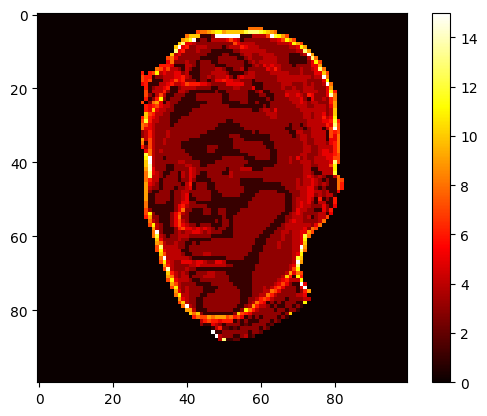

In [9]:
#print(sdf_calls.mean())
print(sdf_calls_2[hit_mask].mean())
plt.imshow(sdf_calls_2.reshape((res, res)).T, cmap='hot', interpolation='nearest')
plt.colorbar()

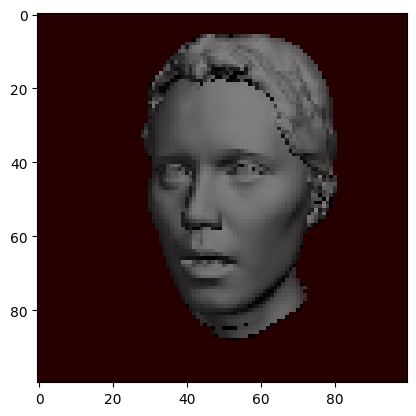

In [5]:
plt.imshow(image.detach().numpy())

In [6]:
prompt="untextured render of woman with short hair"

In [7]:
image_c_first = image.permute(2, 0, 1)
image_preprocessed = clip_tensor_preprocessor(image_c_first).unsqueeze(0)
    
prompt_tokenized = clip.tokenize(prompt).to(device)
    
score = model(image_preprocessed, prompt_tokenized)[0], torch.clone(image)

In [8]:
score[0].backward()